# [LAB 10] 3. 다중로지스틱회귀
## 연습문제

In [29]:
from hossam import load_data
from helpers import *

import numpy as np
from IPython.display import display, Markdown
from pandas import get_dummies

In [12]:
origin = load_data('nursing_grades')
origin.head()

📚 어느 간호학과 대학원에 지원한 학생들에 대한 합격/불합격 여부를 조사한 가상의 데이터(메타데이터 없음)


,접수코드,이름,성별,필기점수,학부성적,병원경력,합격여부
0,NRS0001,장은우,남,380,3.610,3,불합격
1,NRS0002,최지호,남,660,3.670,3,합격
2,NRS0003,김하준,남,800,4.000,1,합격
3,NRS0004,임아윤,여,640,3.190,4,합격
4,NRS0005,강하준,남,520,2.930,4,불합격


In [49]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   접수코드    400 non-null    str    
 1   이름      400 non-null    str    
 2   성별      400 non-null    str    
 3   필기점수    400 non-null    int64  
 4   학부성적    400 non-null    float64
 5   병원경력    400 non-null    int64  
 6   합격여부    400 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 32.5 KB


In [50]:
df1 = my_qtcheck.check_duplicates(origin)

중복된 행의 수: 0


In [51]:
my_qtcheck.check_missing_values(df1)

,Missing Count,Missing Ratio (%)
접수코드,0,0.000
이름,0,0.000
성별,0,0.000
필기점수,0,0.000
학부성적,0,0.000
병원경력,0,0.000
합격여부,0,0.000


In [52]:
df1["합격여부"].value_counts(dropna=False)

합격여부
불합격    250
합격     127
보류      23
Name: count, dtype: int64

In [55]:
df2 = df1[df1["합격여부"] != "보류"].copy()
df2["합격여부"].value_counts(dropna=False)

합격여부
불합격    250
합격     127
Name: count, dtype: int64

In [57]:
my_qtcheck.numerical_summary(df2).T

,필기점수,학부성적,병원경력
count,377.000,377.000,377.000
mean,590.292,3.387,2.467
std,114.957,0.385,0.939
min,220.000,2.260,1.000
25%,520.000,3.120,2.000
50%,580.000,3.400,2.000
75%,680.000,3.670,3.000
max,800.000,4.000,4.000
rel_diff,0.018,0.004,0.233
rdiff_flag,similar,similar,diff


In [64]:
df2 = my_qtcheck.set_type(df2, as_category=["성별", "합격여부"])

<class 'pandas.DataFrame'>
Index: 377 entries, 0 to 399
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   접수코드    377 non-null    str     
 1   이름      377 non-null    str     
 2   성별      377 non-null    category
 3   필기점수    377 non-null    int64   
 4   학부성적    377 non-null    float64 
 5   병원경력    377 non-null    int64   
 6   합격여부    377 non-null    category
dtypes: category(2), float64(1), int64(2), str(2)
memory usage: 24.4 KB


In [65]:
my_qtcheck.categorical_summary(df2)

컬럼 '성별'의 value_counts():


,count
성별,
남,185
여,192


컬럼 '합격여부'의 value_counts():


,count
합격여부,
불합격,250
합격,127


,성별,합격여부
count,377,377
unique,2,2
top,여,불합격
freq,192,250


In [74]:
df3 = df2[["합격여부", "성별", "필기점수", "학부성적", "병원경력"]].copy()

df3 = my_prep.labeling(df3, columns=["합격여부", "성별"])

df3 = df3.astype(float)



합격여부 (2종): 불합격=0, 합격=1
성별 (2종): 남=0, 여=1


In [76]:
xcols = ["성별", "필기점수", "학부성적", "병원경력"]

df4 = my_prep.reduce_vif(
    df3,
    columns=xcols,
    threshold=10.0
)


완료! 남은 변수: ['병원경력', '성별', '필기점수', '학부성적']
최대 VIF = 1.19


In [77]:
df4.head()
df4.info()

<class 'pandas.DataFrame'>
Index: 377 entries, 0 to 399
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   합격여부    377 non-null    float64
 1   성별      377 non-null    float64
 2   필기점수    377 non-null    float64
 3   학부성적    377 non-null    float64
 4   병원경력    377 non-null    float64
dtypes: float64(5)
memory usage: 17.7 KB


In [78]:
fit_base = my_logit.fit_model(df4, y="합격여부", summary=True)

                           Logit Regression Results                           
Dep. Variable:                   합격여부   No. Observations:                  377
Model:                          Logit   Df Residuals:                      372
Method:                           MLE   Df Model:                            4
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                 0.08117
Time:                        10:25:57   Log-Likelihood:                -221.33
converged:                       True   LL-Null:                       -240.88
Covariance Type:            nonrobust   LLR p-value:                 6.629e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5308      1.146     -3.081      0.002      -5.777      -1.285
성별             0.1644      0.231      0.711      0.477      -0.289       0.618
필기점수           0.0021      0.001      1.882      0.0

In [79]:
base_result = my_logit.report_variables(fit_base, df4)
base_result

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,합격여부,학부성적,0.837,0.323,0.330,2.535,0.011,2.310,1.209,4.413,0.849,1.178
1,합격여부,병원경력,-0.559,-0.525,0.130,-4.299,0.000,0.572,0.443,0.738,0.984,1.017
2,합격여부,성별,0.164,0.082,0.231,0.711,0.477,1.179,0.749,1.854,0.989,1.011
3,합격여부,필기점수,0.002,0.240,0.001,1.882,0.060,1.002,1.000,1.004,0.838,1.193



유의하지 않은 독립변수 제거 → 성별 (p = 0.4769)
유의하지 않은 독립변수 제거 → 필기점수 (p = 0.0657)


#### ▶ 모형 적합도

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,합격여부,학부성적,1.065,0.411,0.308,3.458,0.001,2.902,1.587,5.307,0.996,1.004
1,합격여부,병원경력,-0.571,-0.536,0.129,-4.429,0.000,0.565,0.439,0.727,0.996,1.004


**Note. n = 377. LL = -223.297, LL-Null = -240.879, LLR X²(2) = 35.164, p < 0.001, Pseudo R² = 0.073**

합격여부를 종속변수로, 학부성적,병원경력(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR X²(2) = 35.164, p < 0.001 , Pseudo R² = 0.073.

즉, 모형의 유사결정계수는 0.073로 다소 낮은 적합수준을 보였다.

> ※Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

- **학부성적**의 회귀계수는 **B = 1.0653**, 오즈비는 **OR = 2.9017**로 나타났으며, 이는 **합격여부**에 유의한 요인임을 의미한다. (**z = 3.46**, **p < .001**) 즉, **학부성적**가 1 증가할 때 합격여부가 1(사건 발생)이 될 오즈는 평균적으로 약 **190.2% 증가**하는 것으로 해석된다. 
- **병원경력**의 회귀계수는 **B = -0.5709**, 오즈비는 **OR = 0.565**로 나타났으며, 이는 **합격여부**에 유의한 요인임을 의미한다. (**z = -4.43**, **p < .001**) 즉, **병원경력**가 1 증가할 때 합격여부가 1(사건 발생)이 될 오즈는 평균적으로 약 **43.5% 감소**하는 것으로 해석된다. 

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

#### ▶ 오즈비 시각화

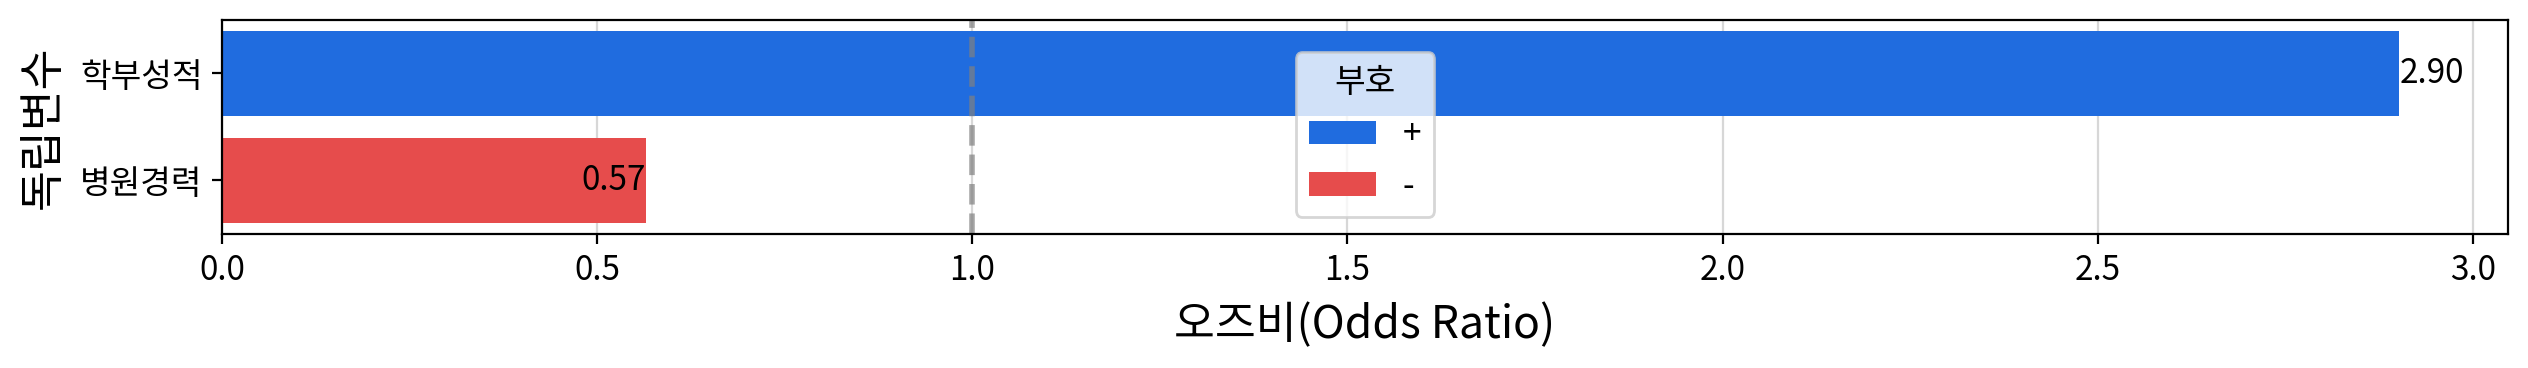

In [80]:
fit_final = my_logit.auto_logit(
    df4,
    y="합격여부",
    backward=True
)